In [1]:
import sys

import json

import matplotlib.pyplot as plt
import numpy
import numpy as np
import pyvista as pv
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.tri as tri

from src.utils import plot_field, ns_residuals

sys.setrecursionlimit(10000)

In [2]:
class AneurysmData:
    def __init__(self, file, w, h):
        mesh = pv.read(file)
        slice_plane = mesh.slice(normal='z')

        edges = slice_plane.extract_feature_edges(boundary_edges=True)
        contour_points = np.array(edges.points)
        contour_points = np.array([[cell[1], cell[0] + 10] for cell in contour_points])

        self.file = file
        self.w = w
        self.h = h
        self.s_h = 14/self.h
        self.s_w = 20/self.w

        self.grid = np.array( [[0 for _ in range(self.w)] for _ in range(self.h)])

        for point in contour_points:
            nearest_cell_x = int(np.floor(point[1] / self.s_w))
            nearest_cell_y = int(np.floor(point[0] / self.s_h))
            self.grid[nearest_cell_y][nearest_cell_x] = 1

        self.__filling(int(h / 2), int(w / 2))
        self.grid[int(h / 2)][int(w / 2)] = 2
        self.__filling_outside()

    @property
    def cells(self):
        r = []
        for i, row in enumerate(self.grid):
            for j, cell in enumerate(row):
                r.append([j , i , cell])
        return r

    @property
    def outside(self):
        return [cell for cell in self.cells if cell[2] == 1]

    @property
    def d_outside(self):
        return np.array([[x * (0.02 / w), y * (0.015 / h), v] for x, y, v in self.cells if v == 1])

    @property
    def inside(self):
        return np.array([cell for cell in self.cells if cell[2] == 2])

    @property
    def d_inside(self):
        return np.array([[x * (0.02 / w), y * (0.015 / h), v] for x, y, v in self.cells if v == 2])

    @property
    def walls(self):
        return np.array([cell for cell in self.cells if cell[2] == 3])

    @property
    def d_walls(self):
        return np.array([[x * (0.02 / w), y * (0.015 / h), v] for x, y, v in self.cells if v == 3])

    def is_outline(self, cell):
        return self.grid[cell[1]][cell[0]] == 1

    def is_inside(self, cell):
        return self.grid[cell[1]][cell[0]] == 2

    def is_true_outside(self, cell):
        return self.grid[cell[1]][cell[0]] == 3

    def get_coords(self, i, j):
        return i * self.s_w, j * self.s_h

    def __filling(self, i, j):
        neigbs = [(i + 1, j), (i - 1, j), (i, j - 1), (i, j + 1)]
        for pixel in neigbs:
            if 0 <= pixel[0] < self.h and 0 <= pixel[1] < self.w:
                if self.grid[pixel[0]][pixel[1]] == 0:
                    self.grid[pixel[0]][pixel[1]] = 2
                    self.__filling(pixel[0], pixel[1])

    def __filling_outside(self):
        for (i, j, _) in self.outside:
            neigbs = [(i + 1, j), (i - 1, j), (i, j - 1), (i, j + 1)]
            for pixel in neigbs:
                if 0 <= pixel[1] < self.h and 0 <= pixel[0] < self.w and self.is_inside(pixel):
                    self.grid[j][i] = 3
                    break

    def plot(self, show_outline=False):
        for cell in self.cells:
            if self.is_outline(cell) and show_outline:
                plt.gca().add_patch(plt.Rectangle(self.get_coords(cell[0], cell[1]), self.s_w, self.s_h, fill=True, color='b'))
            if self.is_inside(cell):
                plt.gca().add_patch(plt.Rectangle(self.get_coords(cell[0], cell[1]), self.s_w, self.s_h, fill=True, color='r'))
            elif self.is_true_outside(cell):
                plt.gca().add_patch(plt.Rectangle(self.get_coords(cell[0], cell[1]), self.s_w, self.s_h, fill=True, color='g'))
            else:
                plt.gca().add_patch(plt.Rectangle(self.get_coords(cell[0], cell[1]), self.s_w, self.s_h, fill=False, lw=0))
        plt.title("Points du contour")
        plt.axis('equal')
        plt.show()

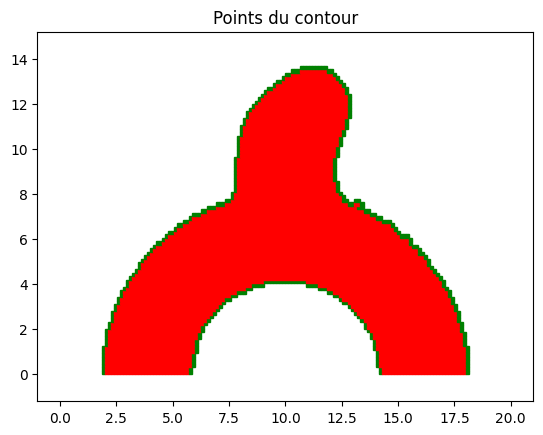

In [3]:
w, h = 150, 90
data = AneurysmData("../AnXplore-main/full_dataset/Solid_77.vtk", w, h)
data.plot()

In [4]:
rho = 1055.0
mu = 0.0035
nu = mu / rho

V_max = 1.114

L_ref = 0.02
P_ref = rho * V_max ** 2  # Pa

Re = V_max * 0.004 / nu

nu = 1 / Re

inlet_radius = 0.09

In [5]:

def parabolic_inlet(x):
    x_center = (x.min() + x.max()) / 2
    R = (x.max() - x.min()) / 2

    return V_max * (1 - ((x - x_center) / R) ** 2)


def increase_points_number(points, n_variations=8, step_size=0.05, noise_std=0.02):
    augmented = [points]

    for _ in range(n_variations):
        # Pas aléatoire dans [-step_size, step_size]
        random_step = (torch.rand_like(points) * 2 - 1) * step_size
        # Ajouter un peu de bruit
        noise = torch.randn_like(points) * noise_std
        # Nouveaux points
        new_points = points + random_step + noise
        augmented.append(new_points)

    return torch.cat(augmented, dim=0)



inside_points = list(np.float64(np.column_stack((data.d_inside[:, 0] / L_ref, data.d_inside[:, 1] / L_ref))))
inside_points = torch.tensor(inside_points).double()

inside_points = increase_points_number(inside_points, 2, 0.001, 0.001)
inside_points = inside_points.detach().requires_grad_(True)


inlet_points = torch.column_stack((
    torch.linspace(0.1, 0.285, 150),
    torch.zeros(150)
)).double()
inlet_points = inlet_points.detach().requires_grad_(True)

inlet_labels = torch.column_stack((
    torch.zeros(len(inlet_points)),
    parabolic_inlet(inlet_points[:, 0].detach())
)).double().detach()


outside_points = torch.tensor(np.float64(np.column_stack((data.d_walls[:, 0] / L_ref, data.d_walls[:, 1] / L_ref)))).double()
outlet_points = torch.tensor(np.float64(np.array([[x * (0.02 / w) / L_ref, y * (0.015 / h) / L_ref] for x, y, _ in
                                                  data.inside[(data.inside[:, 1] == 0) & (data.inside[:, 0] > 50)]]))).double()

outside_points = increase_points_number(outside_points, 8, 0.001, 0.001).detach()
outlet_points  = increase_points_number(outlet_points, 16, 0.001, 0.001).detach()

PINNModel = nn.Sequential(
    nn.Linear(2, 128), nn.Tanh(),
    nn.Linear(128, 128), nn.Tanh(),
    nn.Linear(128, 128), nn.Tanh(),
    nn.Linear(128, 128), nn.Tanh(),
    nn.Linear(128, 3)
).double()
PINNModel.load_state_dict(torch.load("../models/model_30/AN_model_01.pt"))
PINNModel.eval()

/var/folders/sq/58r9s_pj3wn5m42htsn9jh800000gn/T/ipykernel_46781/779602217.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  inside_points = torch.tensor(inside_points).double()


Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): Tanh()
  (6): Linear(in_features=128, out_features=128, bias=True)
  (7): Tanh()
  (8): Linear(in_features=128, out_features=3, bias=True)
)

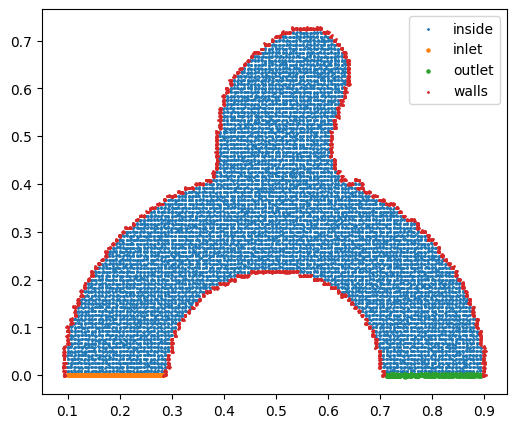

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(inside_points[:,0].detach(), inside_points[:,1].detach(), s=1, label='inside')
plt.scatter(inlet_points[:,0].detach(),  inlet_points[:,1].detach(),  s=5, label='inlet')
plt.scatter(outlet_points[:,0].detach(), outlet_points[:,1].detach(), s=5, label='outlet')
plt.scatter(outside_points[:,0].detach(),outside_points[:,1].detach(),s=1, label='walls')
plt.legend()
plt.show()

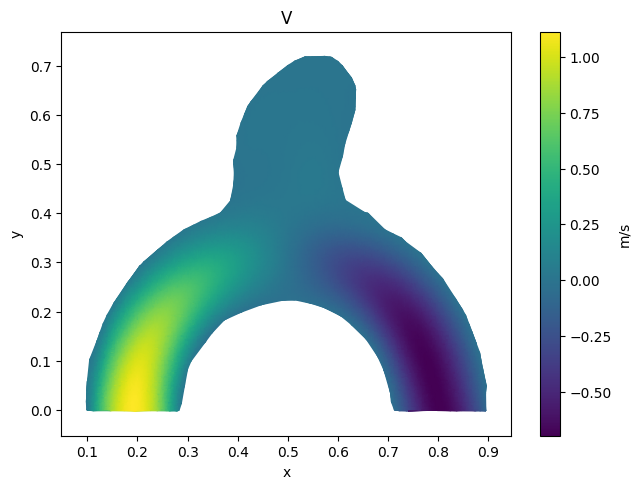

In [19]:
inside_results = PINNModel(inside_points)

x = inside_points.detach().numpy()[:, 0]
y = inside_points.detach().numpy()[:, 1]

u = inside_results.detach().numpy()[:, 0]
v = inside_results.detach().numpy()[:, 1]
p = inside_results.detach().numpy()[:, 2]

plot_field(x, y, v, "V", "m/s", False)

In [8]:
ns = ns_residuals(inside_points, inside_results[:, 0], inside_results[:, 1], inside_results[:, 2], 1/520)

ns_x = ns[0].detach().numpy()
ns_y = ns[1].detach().numpy()
cont = ns[2].detach().numpy()

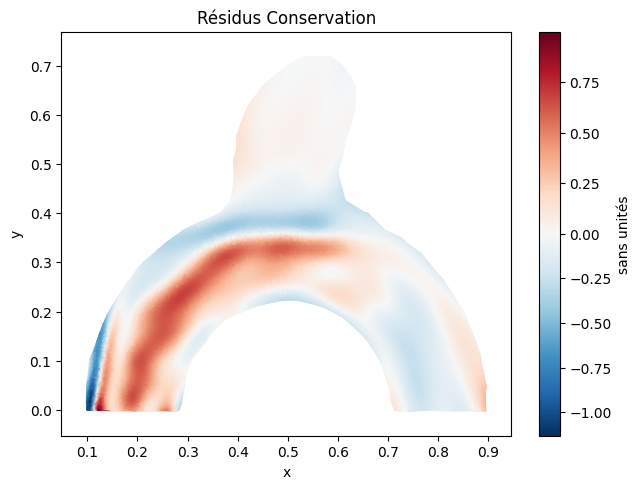

0.9992731697312689


In [9]:
plot_field(x, y, ns_y + ns_x, "Résidus Conservation", "sans unités")
print((ns_y + ns_x).max())